In [1]:
import os

os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


from jax.scipy.stats import norm, poisson
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from diffrax import diffeqsolve, ODETerm
from jax.scipy.stats import norm, poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from time import perf_counter
from algorithms.nuts import nuts
from algorithms.hmc import multi_chain_hmc
from utilities.helpers import effective_sample_size, autocorr_new

# Often import when doing scientific work
jax.config.update("jax_enable_x64", True)


In [2]:
beta = jnp.log(0.4)
eta = jnp.log(1/7)
gamma = jnp.log(1/14)
q= jnp.log(0.1)
mu = jnp.log(0.01)
I0 = jnp.log(0.01)
rho = jnp.log(0.4)

par_true = jnp.array([beta,eta,gamma,q,mu])

t_vec = jnp.linspace(0,50,50)

def SEIR(t,y,args):
  beta,eta,gamma,q,mu = args

  beta = jnp.exp(beta)
  eta = jnp.exp(eta)
  gamma = jnp.exp(gamma)
  q = jnp.exp(q)
  mu = jnp.exp(mu)

  S,E,I,R = y
  N = S+E+I+R

  dS = - beta * ((E + q * I)/N) * S
  dE = beta * ((E + q * I)/N) * S - eta*E - gamma * E
  dI = eta * E - gamma * I - mu * I
  dR = gamma * E + gamma * I


  return jnp.array([dS,dE,dI,dR])

In [3]:
def model(ts, y0, par):
    solution = diffrax.diffeqsolve(
        ODETerm(SEIR),
        diffrax.Dopri5(),
        t0=ts[0],
        t1=ts[-1],
        dt0=0.1,
        y0=y0,
        args=par,
        saveat=diffrax.SaveAt(ts=ts),
    )
    return solution.ys


rng_key = jax.random.PRNGKey(0)

N = 1000
y_true = model(
    t_vec,
    jnp.array([N - N * jnp.exp(I0), N * jnp.exp(I0), 0, 0]),
    (beta, eta, gamma, q, mu),
)

key = jax.random.key(0)

key, I_noise_key = jax.random.split(key)
data_newI = jax.random.poisson(I_noise_key, jnp.exp(rho) * jnp.exp(eta) * y_true[:, 1] + 0.005)

key, D_noise_key = jax.random.split(key)
data_newD = jax.random.poisson(D_noise_key, jnp.exp(mu) * y_true[:, 2] + 0.005)

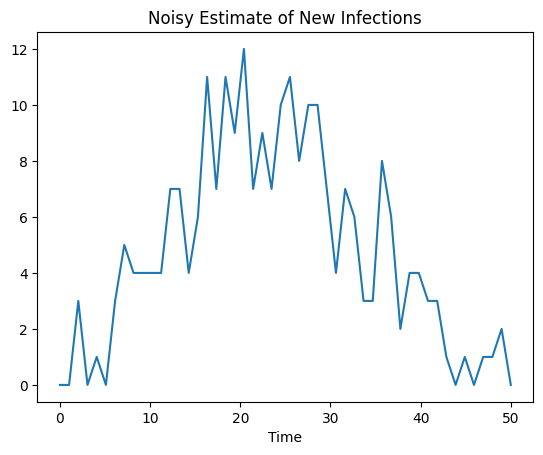

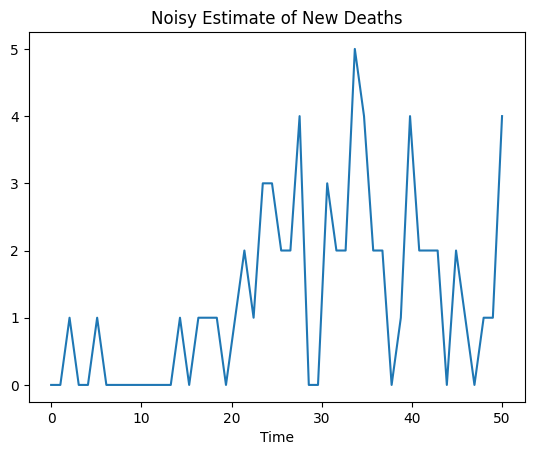

In [4]:
plt.title('Noisy Estimate of New Infections')
plt.plot(t_vec,data_newI)
plt.xlabel('Time')
plt.show()

plt.title('Noisy Estimate of New Deaths')
plt.xlabel('Time')
plt.plot(t_vec,data_newD)
plt.show()

In [5]:
observations = jnp.concatenate((data_newI[:,None],data_newD[:,None]),axis = -1)
print(observations.shape)

(50, 2)


In [6]:
def log_likelihood(par, observations, m, key):

    mask = jnp.arange(observations.shape[0]) < m

    obs_newI = observations[:, 0]
    obs_newD = observations[:, 1]

    N = 1000.0
    beta, eta, gamma, q, mu, I0, rho = par
    model_output = model(
        t_vec,
        jnp.array([N - N * jnp.exp(I0), N * jnp.exp(I0), 0., 0.]),
        (beta, eta, gamma, q, mu),
    )
    pdf_0 = jnp.where(
        mask,
        poisson.logpmf(obs_newI, jnp.exp(rho) * jnp.maximum(jnp.exp(eta) * model_output[:, 1], 1e-6)),
        0.0,
    )
    pdf_1 = jnp.where(
        mask,
        poisson.logpmf(obs_newD, jnp.maximum(jnp.exp(mu) * model_output[:, 2], 1e-6)),
        0.0,
    )
    return jnp.sum(pdf_0 + pdf_1)

In [7]:
from algorithms.smc import ibis

num_particles = 100_000
dim = 7
scale = 0.1
p_init_key, rng_key = jax.random.split(rng_key)
particles = jnp.log(
    jnp.array([0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.1])
) + scale * jax.random.normal(p_init_key, shape=(num_particles, dim))

k = 5
ibis_key, key = jax.random.split(rng_key)
particles = ibis(log_likelihood, observations, k, particles, ibis_key)

Iteration 0 with ESS 100000.00000000004
Iteration 1 with ESS 99968.5769555388
Iteration 2 with ESS 99883.83305381186
Iteration 3 with ESS 73088.55902155563
Iteration 4 with ESS 74424.7314554149
Iteration 5 with ESS 62896.979756666515
Iteration 6 with ESS 53126.961744863285
Iteration 7 with ESS 22489.798775565818
average acceptance rate: 0.7395140000000001 over 5 iterations
Iteration 8 with ESS 3419.6241259096287
average acceptance rate: 0.5969280000000001 over 5 iterations
Iteration 9 with ESS 6286.916530132343
average acceptance rate: 0.4043940000000001 over 5 iterations
Iteration 10 with ESS 74441.59851506815
Iteration 11 with ESS 48250.58547347274
average acceptance rate: 0.33915400000000007 over 5 iterations
Iteration 12 with ESS 84591.30126613588
Iteration 13 with ESS 53289.91333408336
Iteration 14 with ESS 31128.469471325476
average acceptance rate: 0.23624200000000004 over 5 iterations
Iteration 15 with ESS 73454.19408249305
Iteration 16 with ESS 71555.39751385472
Iteration 17 w

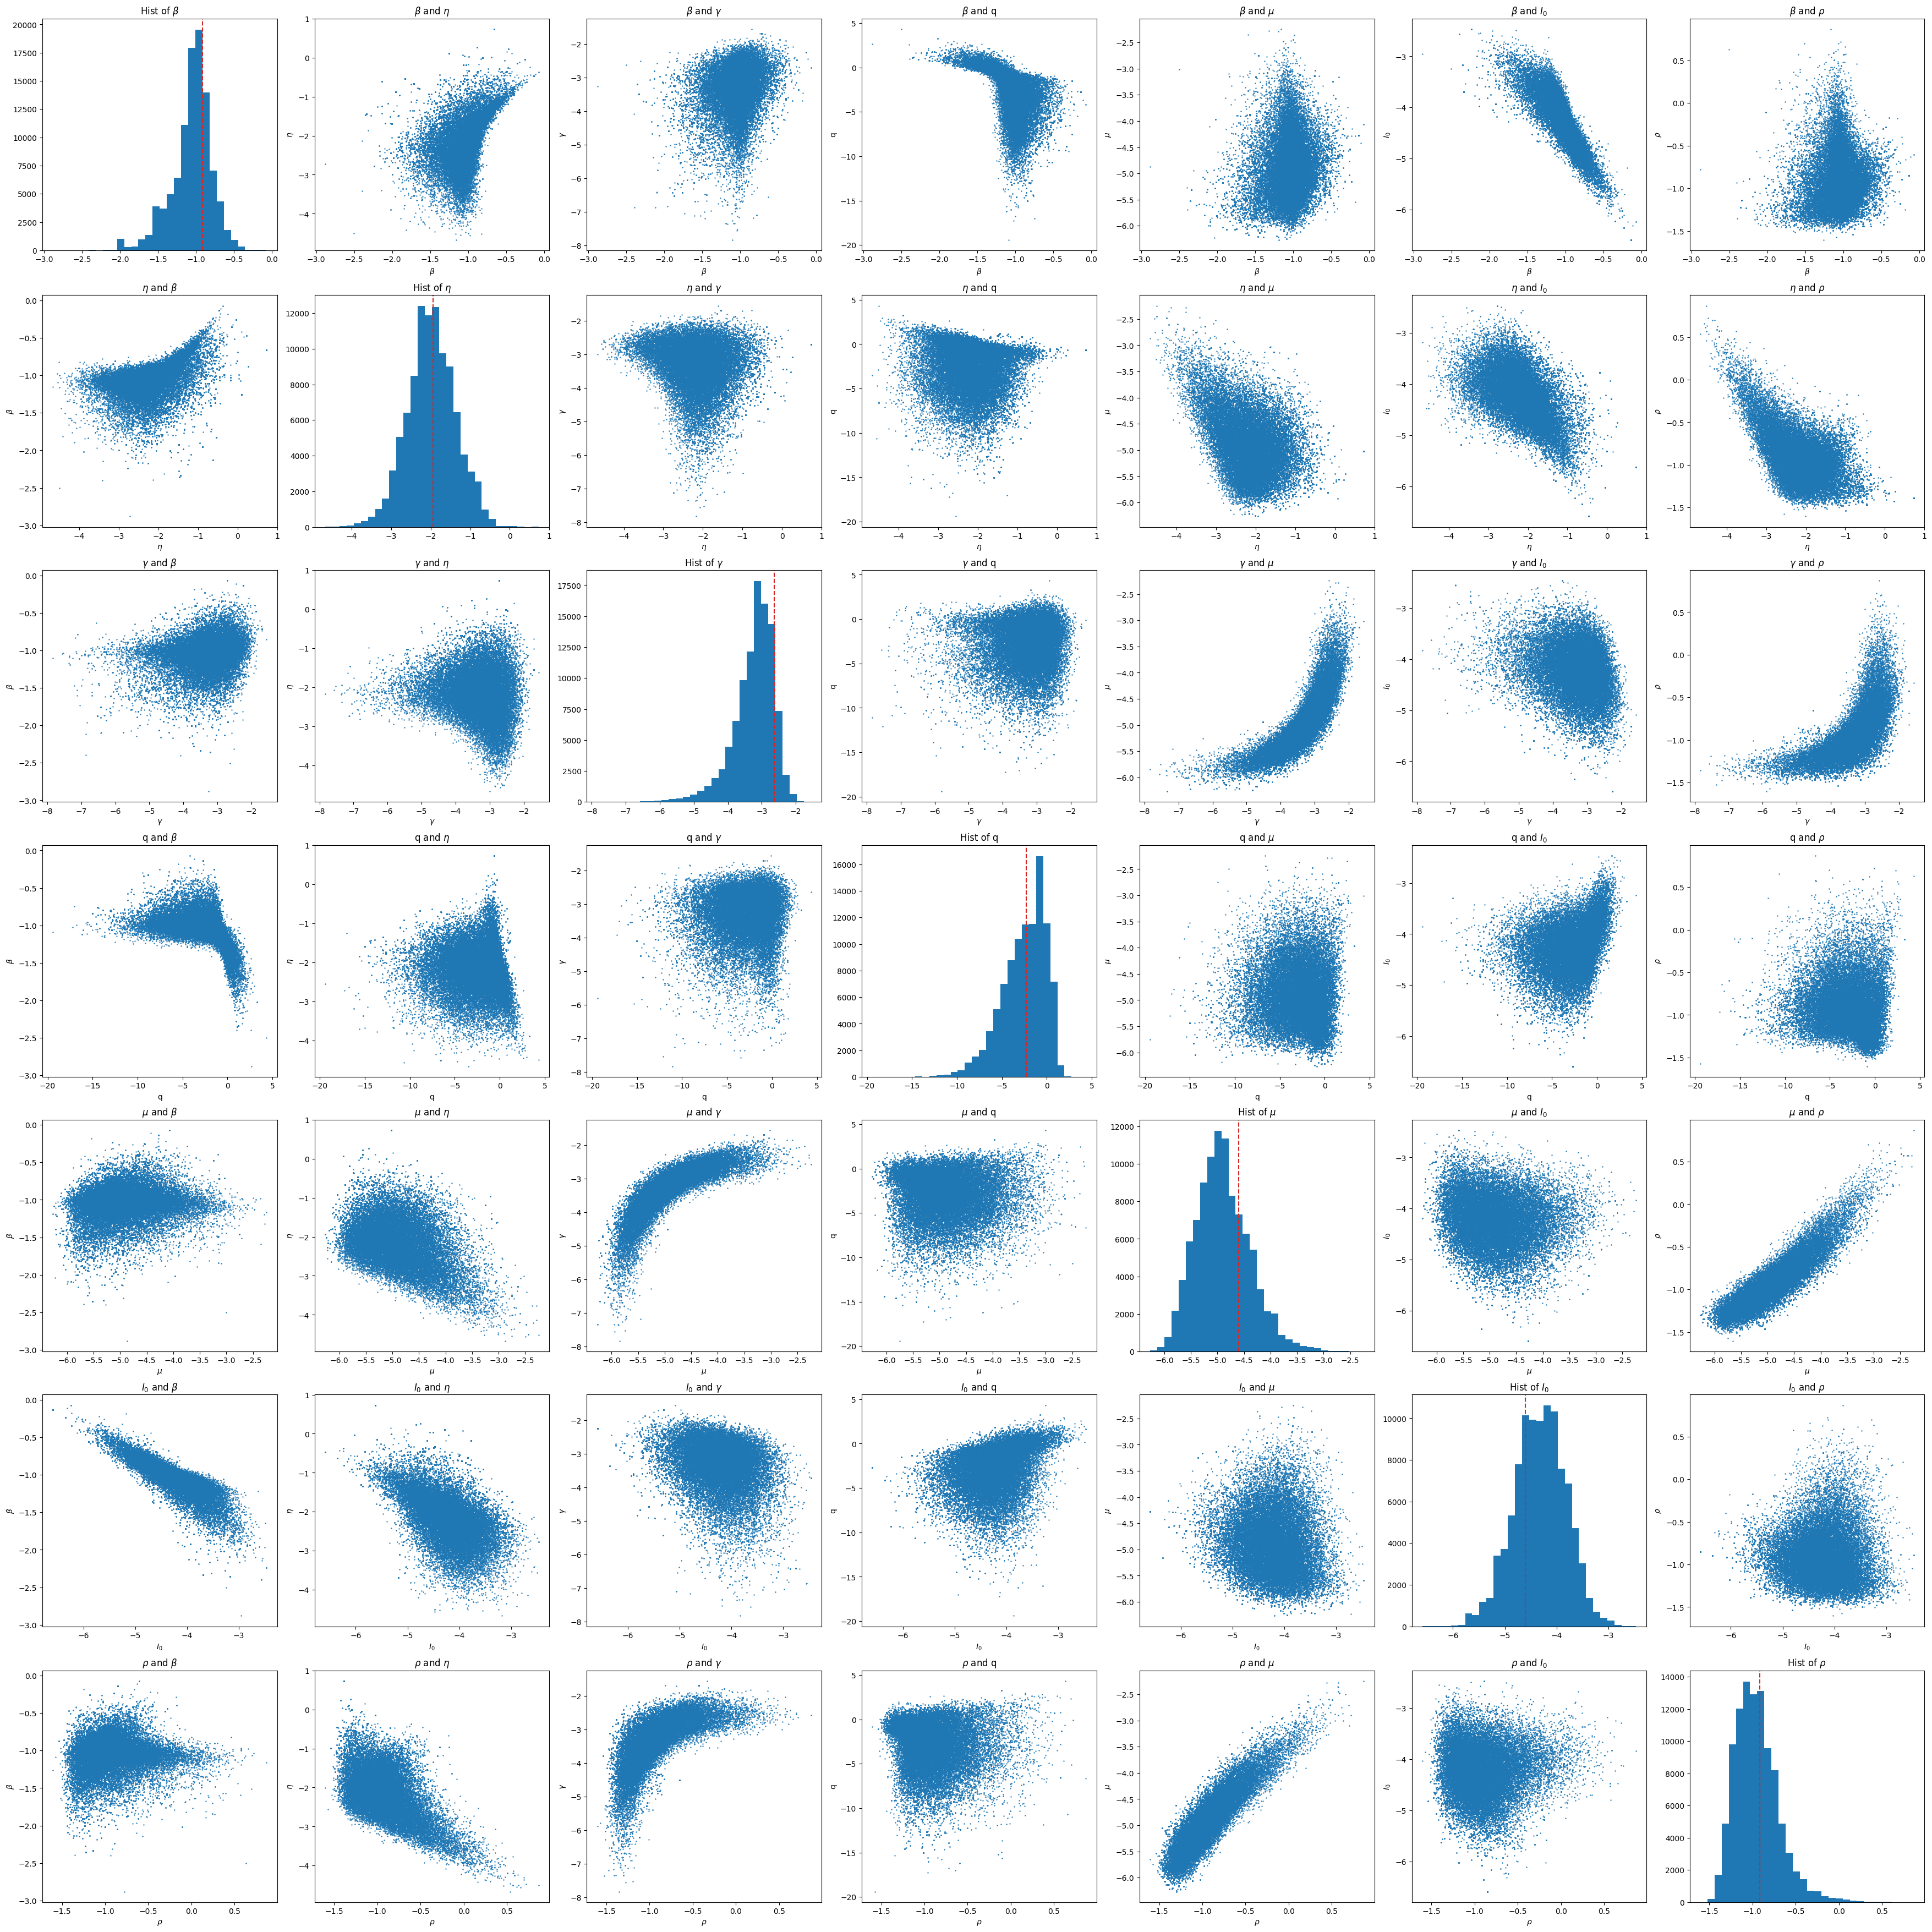

In [8]:
fig, axes = plt.subplots(dim, dim, figsize=(5 * dim, 5 * dim), layout="constrained")

par_names = ["$\\beta$", "$\\eta$", "$\\gamma$", "q", "$\\mu$", "$I_0$", "$\\rho$"]
true_params = [beta, eta, gamma, q, mu, I0, rho]

for par1_index in range(dim):
    for par2_index in range(dim):
        if par1_index != par2_index:
            axes[par1_index, par2_index].set_title(
                f"{par_names[par1_index]} and {par_names[par2_index]}"
            )
            axes[par1_index, par2_index].scatter(
                particles[:, par1_index],
                particles[:, par2_index],
                s=0.5,
            )
            axes[par1_index, par2_index].set_xlabel(f"{par_names[par1_index]}")
            axes[par1_index, par2_index].set_ylabel(f"{par_names[par2_index]}")

        else:
            axes[par1_index, par2_index].hist(particles[:, par1_index], bins=30)
            axes[par1_index, par2_index].set_title(f"Hist of {par_names[par1_index]}")
            axes[par1_index, par2_index].axvline(
                true_params[par1_index], color="tab:red", ls="dashed"
            )

plt.show()